In [15]:
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier
import missingno as msno
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve)

%matplotlib inline

In [16]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
SENTINEL_OUTGOINGS = -1
FEATURES = ['Income', 'Outgoings', 'NetDisposable']
OUTPUT_DIR = 'Output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [17]:
# load the dataset

df = pd.read_csv('./Data/previousApplicants.csv')

In [18]:
# plot missing data 

def plot_missing_data(df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Missing data matrix - shows location of nulls
    msno.matrix(df, ax=axes[0], sparkline=False, fontsize=10)
    axes[0].set_title("Missing Data Matrix (Raw Data)", fontsize=13, fontweight="bold")

    # Bar chart of completeness per column
    msno.bar(df, ax=axes[1], fontsize=10, color="steelblue")
    axes[1].set_title("Column Completeness (Raw Data)", fontsize=13, fontweight="bold")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"missing_data_overview.png"), dpi=150)
    plt.show()


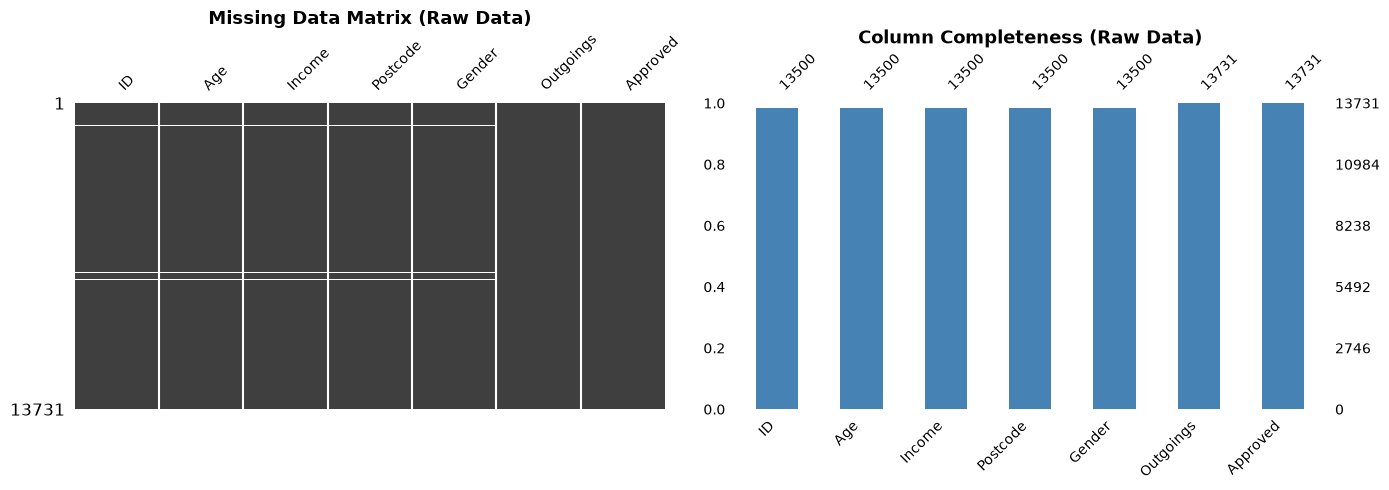

In [20]:
plot_missing_data(df)

In [21]:
# check for missing values in the dataset
df.isnull().sum()

ID           231
Age          231
Income       231
Postcode     231
Gender       231
Outgoings      0
Approved       0
dtype: int64

In [22]:
# check for unique values in the dataset
df.nunique()

ID           12500
Age             79
Income       11977
Postcode     12454
Gender           3
Outgoings     9768
Approved         2
dtype: int64

In [26]:
# check for gender type count in the dataset
df['Gender'].value_counts()

Gender
a    6785
b    6714
c       1
Name: count, dtype: int64

ID
456724232.0    2
456726207.0    2
456728380.0    2
456729087.0    2
456729932.0    2
              ..
457973158.0    1
457973307.0    1
457973386.0    1
457973495.0    1
457973586.0    1
Name: count, Length: 12500, dtype: int64

In [ ]:
# Clean the dataset by removing rows with missing IDs, replacing 'nil' in Income with NaN, and replacing SENTINEL_OUTGOINGS in Outgoings with NaN. Then, group by ID and aggregate the first non-null values for each column.
def clean_data(df):
    df = df[df['ID'].notna()].copy()

    df['Income'] = df['Income'].replace('nil', pd.NA)
    df['Outgoings'] = df['Outgoings'].astype(str).replace(SENTINEL_OUTGOINGS, pd.NA)

    cleaned_df = (df.sort_values(by='ID').groupby('ID', as_index=False).agg({
        'Age': 'first', 
        'Postcode': 'first', 
        'Gender': 'first', 
        'Approved': 'first', 
        'Income': lambda s: s.dropna().iloc[0] if s.notna().any() else pd.NA,
        'Outgoings': lambda s: s.dropna().iloc[0] if s.notna().any() else pd.NA,
    }))

    cleaned_df['ID'] = cleaned_df['ID'].astype(int)
    cleaned_df['Age'] = cleaned_df['Age'].astype(int)
    cleaned_df['Income'] = cleaned_df['Income'].astype(float).astype(int)
    cleaned_df['Outgoings'] = cleaned_df['Outgoings'].astype(float).astype(int)
    cleaned_df['Approved'] = cleaned_df['Approved'].astype(bool)

    return cleaned_df

clean_data(df)

,ID,Age,Postcode,Gender,Approved,Income,Outgoings
0,456723624,76,WA7 1SJ,b,True,116014,12732
1,456723677,29,WS10 9BG,b,True,119177,1211
2,456723829,81,SW1V 3HS,b,True,142052,816
3,456723872,24,DE24 8GN,b,False,43451,21794
4,456723973,25,BR4 0HL,a,False,54961,22791
...,...,...,...,...,...,...,...
12495,457973158,44,BT23 6NU,b,False,68784,23000
12496,457973307,93,CW12 3LF,b,True,146137,2264
12497,457973386,72,EH3 9HB,a,False,124526,11048
12498,457973495,81,RM3 9LX,b,True,72182,4897


In [ ]:
# Feature engineering: Create a new column 'NetDisposable' by subtracting 'Outgoings' from 'Income'.
def build_features(df):
    df = df.copy()
    df['NetDisposable'] = df['Income'] - df['Outgoings']

    return df

In [36]:
def make_model():
    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        regularization_lambda=1,
        eval_metric='logloss',
        random_state=RANDOM_STATE
    )
    return model

In [37]:
# Train model

def train_model(df):
    X = df[FEATURES]
    y = df['Approved'].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

    model = make_model()
    model.fit(X_train, y_train)

    cv = cross_val_score(make_model(), X_train, y_train, cv=5, scoring='roc_auc')

    print(f"5-fold CV ROC-AUC: {cv.mean():.3f} (+/-{cv.std():.3f})")

    return {'model': model, 'X_train': X_train, 'X_test': X_test, 'y_train': y_train, 'y_test': y_test}


In [38]:
def evaluate_model(bundle):
    model, X_test, y_test = bundle['model'], bundle['X_test'], bundle['y_test']
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
 
    row = {'Accuracy': accuracy_score(y_test, pred),
           'Precision': precision_score(y_test, pred),
           'Recall': recall_score(y_test, pred),
           'F1': f1_score(y_test, pred),
           'ROC_AUC': roc_auc_score(y_test, proba)}
    print("\nXGBoost test-set metrics:")
    for k, v in row.items():
        print(f"  {k:10s}: {v:.4f}")
    print("\nClassification report:\n",
          classification_report(y_test, pred, target_names=['Rejected', 'Approved']))
    return {'pred': pred, 'proba': proba, 'metrics': row}
